✅ Data Loaded Successfully.

--- 🧪 Grouping Statistics ---
Solvent Families Identified: 8
Polymer Families Identified: 5

Features used: ['mn', 'mw', 'dens', 'temperature', 'dielectric_constant', 'molar_refractivity', 'radius_of_gyration_square', 'branching', 'solvent_mol_wt', 'solvent_mol_mr', 'solvent_tpsa', 'solvent_h_donors', 'solvent_h_acceptors']

--- Generalization: Unseen Polymer Identity ---
R²:   0.3280
MAE:  84.8005 K
RMSE: 106.7263 K

--- Generalization: Unseen Solvent Identity ---
R²:   0.9607
MAE:  7.1467 K
RMSE: 25.8173 K

--- Generalization: Unseen Polymer Family ---
R²:   0.0563
MAE:  100.6362 K
RMSE: 126.4789 K

--- Generalization: Unseen Solvent Family ---
R²:   0.8024
MAE:  29.4027 K
RMSE: 57.8733 K


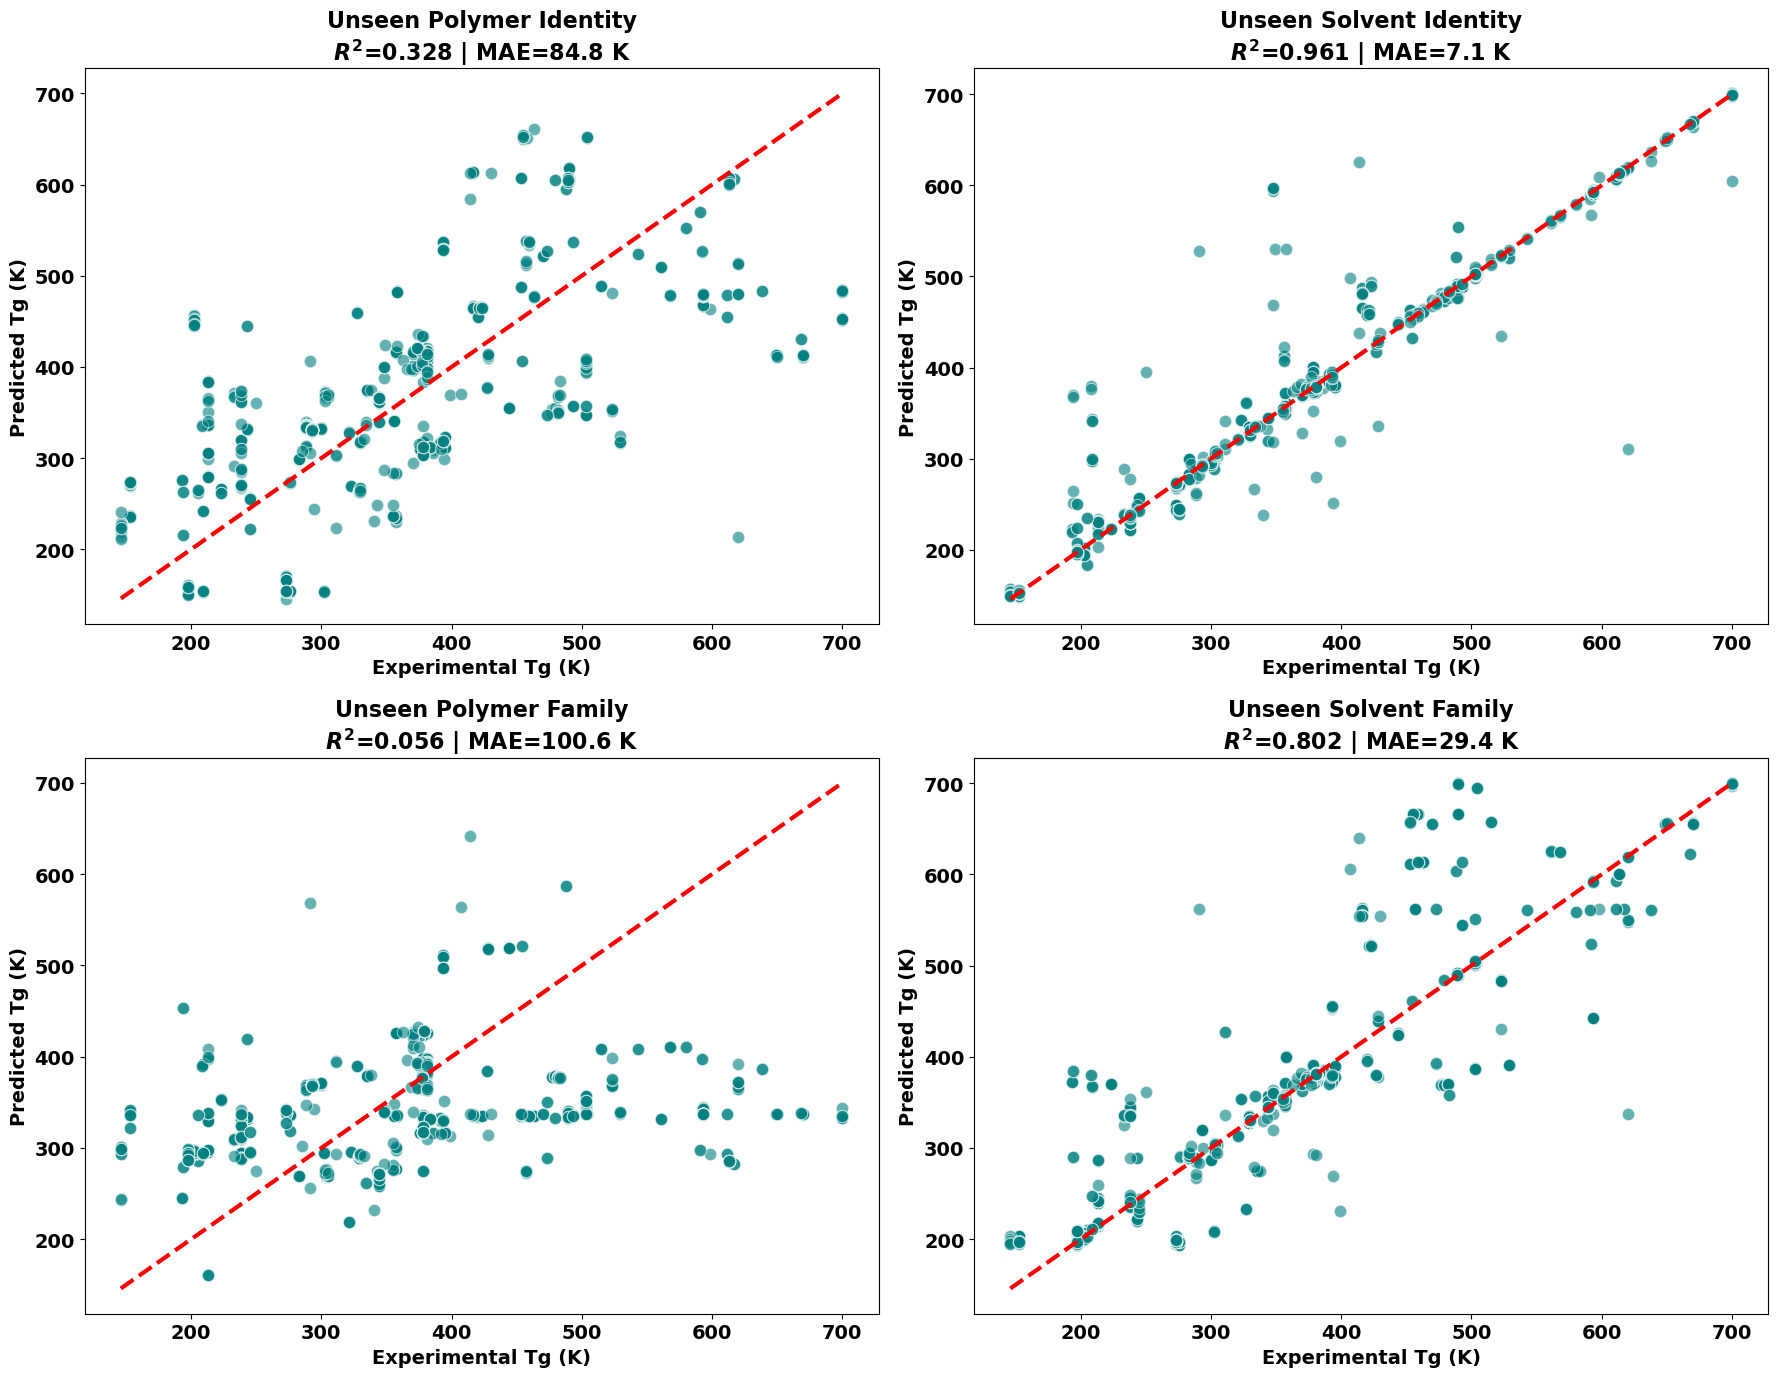

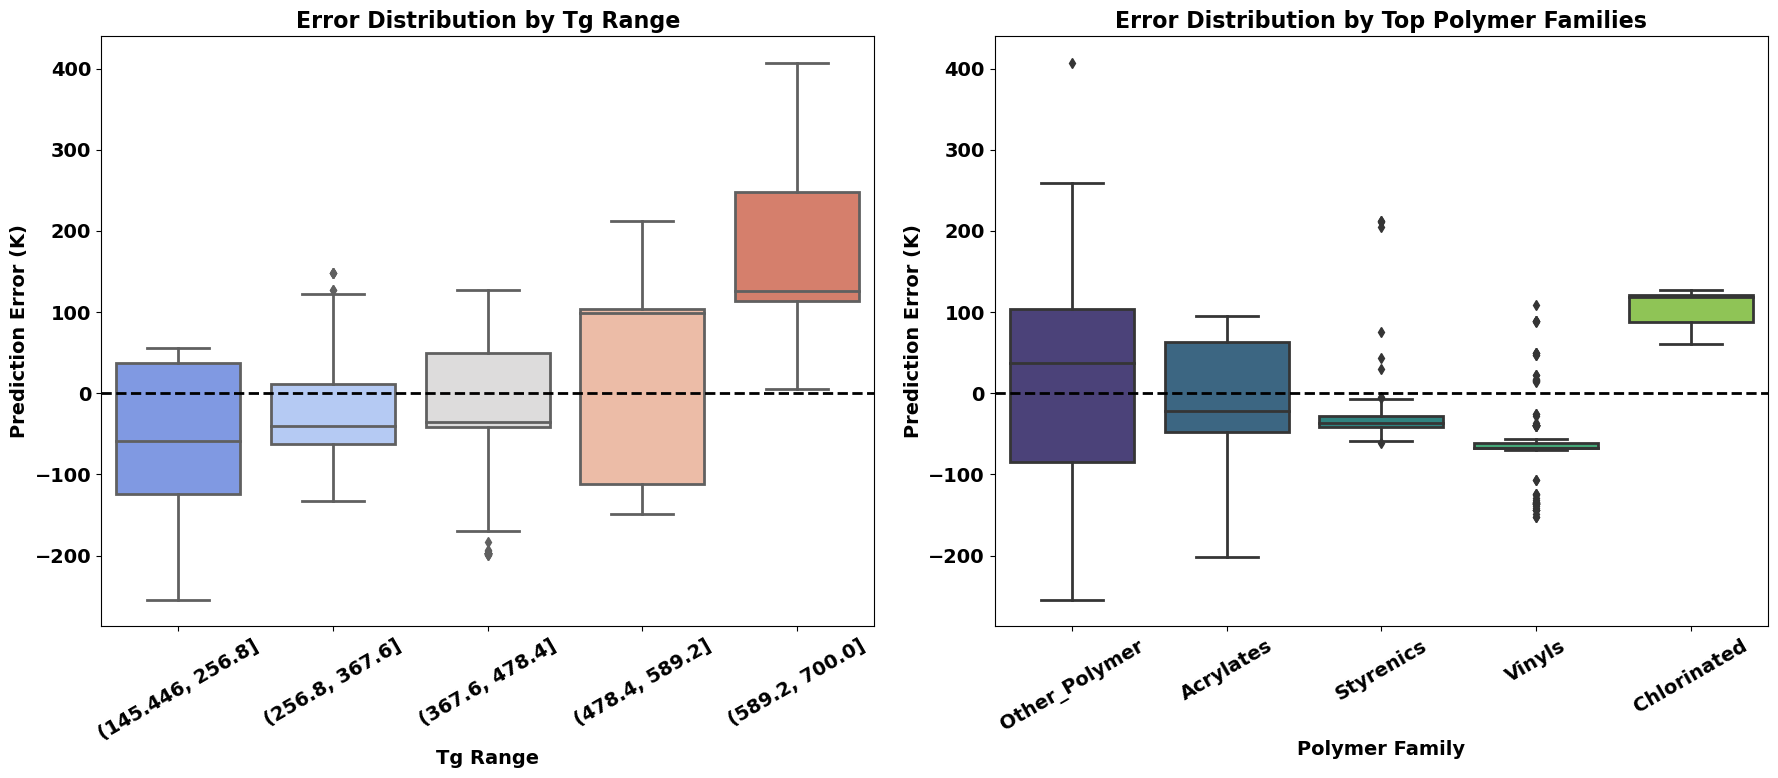

In [4]:
# import pandas as pd
# import numpy as np
# import xgboost as xgb
# from sklearn.model_selection import GroupKFold, cross_val_predict
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from sklearn.preprocessing import RobustScaler
# from sklearn.impute import KNNImputer
# from sklearn.pipeline import Pipeline
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ==========================================
# # 1. DATA LOADING & PREPARATION
# # ==========================================
# try:
#     df = pd.read_csv('data_augmented.csv')
#     print("✅ Data Loaded Successfully.")
# except FileNotFoundError:
#     print("❌ Error: 'data_augmented.csv' not found.")
#     # Stop execution if data is missing, or create dummy data for testing
#     df = pd.DataFrame() 

# if not df.empty:
#     # ==========================================
#     # 2. DEFINE CHEMICAL FAMILIES (For "Grouped" Validation)
#     # ==========================================
#     # This addresses the reviewer's request to test "Generalization to Unseen Families"
    
#     def assign_solvent_family(name):
#         name = str(name).lower()
#         if any(x in name for x in ['benzene', 'toluene', 'xylene', 'phenol', 'styrene', 'mesitylene']):
#             return 'Aromatic'
#         elif any(x in name for x in ['ol', 'alcohol', 'methanol', 'ethanol', 'propanol']):
#             return 'Alcohol'
#         elif any(x in name for x in ['chloro', 'floro', 'bromo', 'iod', 'ccl4']):
#             return 'Halogenated'
#         elif any(x in name for x in ['one', 'ketone', 'acetone', 'mkp']):
#             return 'Ketone'
#         elif any(x in name for x in ['acetate', 'ester']):
#             return 'Ester'
#         elif any(x in name for x in ['ether', 'thf', 'dioxane']):
#             return 'Ether'
#         elif 'water' in name:
#             return 'Water'
#         else:
#             return 'Other_Solvent'

#     def assign_polymer_family(name):
#         name = str(name).lower()
#         if any(x in name for x in ['acrylate', 'pmma', 'pma', 'methacrylate']):
#             return 'Acrylates'
#         elif any(x in name for x in ['styrene', 'ps', 'pms']):
#             return 'Styrenics'
#         elif any(x in name for x in ['oxide', 'peo', 'peg', 'ppo']):
#             return 'Polyoxides'
#         elif any(x in name for x in ['chloride', 'pvc']):
#             return 'Chlorinated'
#         elif any(x in name for x in ['vinyl', 'pva', 'pvp', 'acetate']):
#             return 'Vinyls'
#         else:
#             return 'Other_Polymer'

#     # Apply groupings
#     df['Solvent_Family'] = df['solvent_name'].apply(assign_solvent_family)
#     df['Polymer_Family'] = df['polymer_name'].apply(assign_polymer_family)

#     print("\n--- 🧪 Grouping Statistics ---")
#     print(f"Solvent Families Identified: {df['Solvent_Family'].nunique()}")
#     print(f"Polymer Families Identified: {df['Polymer_Family'].nunique()}")

#     # ==========================================
#     # 3. FEATURE SELECTION (PREVENT LEAKAGE)
#     # ==========================================
#     # CRITICAL: Drop all identifiers to rule out "Identifier Learning"
#     exclude_cols = [
#         'polymer_name', 'solvent_name', 
#         'polymer_smiles', 'solvent_smiles', 'solvent_formula', 
#         'radius_of_gyration', # Dropped based on previous context
#         'Solvent_Category', 'Solvent_Family', 'Polymer_Family', 'tg'
#     ]
    
#     # Select only numeric physical descriptors
#     feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64', 'int64']]
#     print(f"\nFeatures used for Physics-Only Validation ({len(feature_cols)}):")
#     print(feature_cols)

#     X = df[feature_cols]
#     y = df['tg']

#     # ==========================================
#     # 4. ROBUST EVALUATION FUNCTION
#     # ==========================================
#     def run_grouped_validation(X, y, groups, test_name):
#         """
#         Runs GroupKFold Cross-Validation.
#         Ensures that if Group A is in Test, NO samples from Group A are in Train.
#         """
#         # Check if we have enough groups for 5-fold
#         n_groups = groups.nunique()
#         n_splits = 5 if n_groups >= 5 else n_groups
        
#         if n_splits < 2:
#             print(f"\n⚠️ Skipping {test_name}: Not enough groups ({n_groups}) for cross-validation.")
#             return None, 0, 0, 0

#         gkf = GroupKFold(n_splits=n_splits)
        
#         # Pipeline: Impute -> Scale -> Model
#         pipeline = Pipeline([
#             ('imputer', KNNImputer(n_neighbors=5)),
#             ('scaler', RobustScaler()),
#             ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1))
#         ])
        
#         # Get out-of-sample predictions
#         y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, n_jobs=-1)
        
#         # Metrics
#         r2 = r2_score(y, y_pred)
#         mae = mean_absolute_error(y, y_pred)
#         rmse = np.sqrt(mean_squared_error(y, y_pred))
        
#         print(f"\n--- {test_name} ---")
#         print(f"R²:   {r2:.4f}")
#         print(f"MAE:  {mae:.4f} K")
#         print(f"RMSE: {rmse:.4f} K")
        
#         return y_pred, r2, mae, rmse

#     # ==========================================
#     # 5. EXECUTE 4-LEVEL VALIDATION
#     # ==========================================
    
#     # A. Unseen Polymer Identity (Hard)
#     pred_poly_id, r2_pid, mae_pid, _ = run_grouped_validation(
#         X, y, groups=df['polymer_name'], test_name="Generalization: Unseen Polymer Identity"
#     )

#     # B. Unseen Solvent Identity (Medium)
#     pred_solv_id, r2_sid, mae_sid, _ = run_grouped_validation(
#         X, y, groups=df['solvent_name'], test_name="Generalization: Unseen Solvent Identity"
#     )
    
#     # C. Unseen Polymer Family (Very Hard)
#     pred_poly_fam, r2_pfam, mae_pfam, _ = run_grouped_validation(
#         X, y, groups=df['Polymer_Family'], test_name="Generalization: Unseen Polymer Family"
#     )

#     # D. Unseen Solvent Family (Medium-Hard)
#     pred_solv_fam, r2_sfam, mae_sfam, _ = run_grouped_validation(
#         X, y, groups=df['Solvent_Family'], test_name="Generalization: Unseen Solvent Family"
#     )

#     # ==========================================
#     # 6. VISUALIZATION: PARITY PLOTS
#     # ==========================================
#     fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
#     # Helper to plot
#     def plot_parity(ax, y_true, y_pred, title, r2, mae):
#         if y_pred is None: return
#         sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, ax=ax, color='teal')
#         ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
#         ax.set_title(f"{title}\nR²={r2:.3f} | MAE={mae:.1f} K", fontsize=12)
#         ax.set_xlabel("Experimental Tg (K)")
#         ax.set_ylabel("Predicted Tg (K)")

#     plot_parity(axes[0,0], y, pred_poly_id, "Unseen Polymer Identity", r2_pid, mae_pid)
#     plot_parity(axes[0,1], y, pred_solv_id, "Unseen Solvent Identity", r2_sid, mae_sid)
#     plot_parity(axes[1,0], y, pred_poly_fam, "Unseen Polymer Family", r2_pfam, mae_pfam)
#     plot_parity(axes[1,1], y, pred_solv_fam, "Unseen Solvent Family", r2_sfam, mae_sfam)
    
#     plt.tight_layout()
#     plt.show()

#     # ==========================================
#     # 7. ERROR DISTRIBUTION ANALYSIS (As requested)
#     # ==========================================
#     # We analyze errors specifically for "Unseen Polymer Identity" as it's the primary risk
#     if pred_poly_id is not None:
#         residuals = y - pred_poly_id
#         df['Error'] = residuals
#         df['Abs_Error'] = residuals.abs()
        
#         # Bin Tg values
#         df['Tg_Range'] = pd.cut(df['tg'], bins=5)
        
#         fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
        
#         # Plot 1: Error by Tg Range
#         sns.boxplot(x='Tg_Range', y='Error', data=df, ax=axes2[0], palette="coolwarm")
#         axes2[0].axhline(0, color='black', linestyle='--')
#         axes2[0].set_title("Error Distribution by Tg Range (Unseen Polymers)")
#         axes2[0].tick_params(axis='x', rotation=30)
        
#         # Plot 2: Error by Polymer Family
#         # Filter for top 6 largest families to keep plot clean
#         top_fam = df['Polymer_Family'].value_counts().head(6).index
#         df_top_fam = df[df['Polymer_Family'].isin(top_fam)]
        
#         sns.boxplot(x='Polymer_Family', y='Error', data=df_top_fam, ax=axes2[1], palette="viridis")
#         axes2[1].axhline(0, color='black', linestyle='--')
#         axes2[1].set_title("Error Distribution by Top Polymer Families")
#         axes2[1].tick_params(axis='x', rotation=30)
        
#         plt.tight_layout()
#         plt.show()

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. GLOBAL PLOT STYLING (The Update)
# ==========================================
plt.rcParams.update({
    'font.size': 14,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.titlesize': 18,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'legend.title_fontsize': 16
})

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
try:
    df = pd.read_csv('data_augmented.csv')
    print("✅ Data Loaded Successfully.")
except FileNotFoundError:
    print("❌ Error: 'data_augmented.csv' not found. Please ensure the file exists.")
    df = pd.DataFrame() 

if not df.empty:
    # ==========================================
    # 2. DEFINE CHEMICAL FAMILIES
    # ==========================================
    def assign_solvent_family(name):
        name = str(name).lower()
        if any(x in name for x in ['benzene', 'toluene', 'xylene', 'phenol', 'styrene', 'mesitylene']):
            return 'Aromatic'
        elif any(x in name for x in ['ol', 'alcohol', 'methanol', 'ethanol', 'propanol']):
            return 'Alcohol'
        elif any(x in name for x in ['chloro', 'floro', 'bromo', 'iod', 'ccl4']):
            return 'Halogenated'
        elif any(x in name for x in ['one', 'ketone', 'acetone', 'mkp']):
            return 'Ketone'
        elif any(x in name for x in ['acetate', 'ester']):
            return 'Ester'
        elif any(x in name for x in ['ether', 'thf', 'dioxane']):
            return 'Ether'
        elif 'water' in name:
            return 'Water'
        else:
            return 'Other_Solvent'

    def assign_polymer_family(name):
        name = str(name).lower()
        if any(x in name for x in ['acrylate', 'pmma', 'pma', 'methacrylate']):
            return 'Acrylates'
        elif any(x in name for x in ['styrene', 'ps', 'pms']):
            return 'Styrenics'
        elif any(x in name for x in ['oxide', 'peo', 'peg', 'ppo']):
            return 'Polyoxides'
        elif any(x in name for x in ['chloride', 'pvc']):
            return 'Chlorinated'
        elif any(x in name for x in ['vinyl', 'pva', 'pvp', 'acetate']):
            return 'Vinyls'
        else:
            return 'Other_Polymer'

    # Apply groupings
    df['Solvent_Family'] = df['solvent_name'].apply(assign_solvent_family)
    df['Polymer_Family'] = df['polymer_name'].apply(assign_polymer_family)

    print("\n--- 🧪 Grouping Statistics ---")
    print(f"Solvent Families Identified: {df['Solvent_Family'].nunique()}")
    print(f"Polymer Families Identified: {df['Polymer_Family'].nunique()}")

    # ==========================================
    # 3. FEATURE SELECTION
    # ==========================================
    exclude_cols = [
        'polymer_name', 'solvent_name', 
        'polymer_smiles', 'solvent_smiles', 'solvent_formula', 
        'radius_of_gyration', 
        'Solvent_Category', 'Solvent_Family', 'Polymer_Family', 'tg'
    ]
    
    feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64', 'int64']]
    print(f"\nFeatures used: {feature_cols}")

    X = df[feature_cols]
    y = df['tg']

    # ==========================================
    # 4. ROBUST EVALUATION FUNCTION
    # ==========================================
    def run_grouped_validation(X, y, groups, test_name):
        n_groups = groups.nunique()
        n_splits = 5 if n_groups >= 5 else n_groups
        
        if n_splits < 2:
            print(f"\n⚠️ Skipping {test_name}: Not enough groups ({n_groups}).")
            return None, 0, 0, 0

        gkf = GroupKFold(n_splits=n_splits)
        
        pipeline = Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', RobustScaler()),
            ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1))
        ])
        
        y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, n_jobs=-1)
        
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        
        print(f"\n--- {test_name} ---")
        print(f"R²:   {r2:.4f}")
        print(f"MAE:  {mae:.4f} K")
        print(f"RMSE: {rmse:.4f} K")
        
        return y_pred, r2, mae, rmse

    # ==========================================
    # 5. EXECUTE 4-LEVEL VALIDATION
    # ==========================================
    # A. Unseen Polymer Identity
    pred_poly_id, r2_pid, mae_pid, _ = run_grouped_validation(
        X, y, groups=df['polymer_name'], test_name="Generalization: Unseen Polymer Identity"
    )

    # B. Unseen Solvent Identity
    pred_solv_id, r2_sid, mae_sid, _ = run_grouped_validation(
        X, y, groups=df['solvent_name'], test_name="Generalization: Unseen Solvent Identity"
    )
    
    # C. Unseen Polymer Family
    pred_poly_fam, r2_pfam, mae_pfam, _ = run_grouped_validation(
        X, y, groups=df['Polymer_Family'], test_name="Generalization: Unseen Polymer Family"
    )

    # D. Unseen Solvent Family
    pred_solv_fam, r2_sfam, mae_sfam, _ = run_grouped_validation(
        X, y, groups=df['Solvent_Family'], test_name="Generalization: Unseen Solvent Family"
    )

    # ==========================================
    # 6. VISUALIZATION: PARITY PLOTS (BOLD & BIG)
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14)) # Increased figure size
    
    def plot_parity(ax, y_true, y_pred, title, r2, mae):
        if y_pred is None: return
        sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, ax=ax, color='teal', s=80) # Increased dot size
        ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=3) # Thicker line
        
        # Bold title with metrics
        ax.set_title(f"{title}\n$R^2$={r2:.3f} | MAE={mae:.1f} K", fontweight='bold')
        ax.set_xlabel("Experimental Tg (K)", fontweight='bold')
        ax.set_ylabel("Predicted Tg (K)", fontweight='bold')

    plot_parity(axes[0,0], y, pred_poly_id, "Unseen Polymer Identity", r2_pid, mae_pid)
    plot_parity(axes[0,1], y, pred_solv_id, "Unseen Solvent Identity", r2_sid, mae_sid)
    plot_parity(axes[1,0], y, pred_poly_fam, "Unseen Polymer Family", r2_pfam, mae_pfam)
    plot_parity(axes[1,1], y, pred_solv_fam, "Unseen Solvent Family", r2_sfam, mae_sfam)
    
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 7. ERROR DISTRIBUTION ANALYSIS (BOLD & BIG)
    # ==========================================
    if pred_poly_id is not None:
        residuals = y - pred_poly_id
        df['Error'] = residuals
        df['Abs_Error'] = residuals.abs()
        
        # Bin Tg values
        df['Tg_Range'] = pd.cut(df['tg'], bins=5)
        
        fig2, axes2 = plt.subplots(1, 2, figsize=(18, 8)) # Increased figure size
        
        # Plot 1: Error by Tg Range
        sns.boxplot(x='Tg_Range', y='Error', data=df, ax=axes2[0], palette="coolwarm", linewidth=2)
        axes2[0].axhline(0, color='black', linestyle='--', linewidth=2)
        axes2[0].set_title("Error Distribution by Tg Range", fontweight='bold')
        axes2[0].set_xlabel("Tg Range", fontweight='bold')
        axes2[0].set_ylabel("Prediction Error (K)", fontweight='bold')
        axes2[0].tick_params(axis='x', rotation=30)
        
        # Plot 2: Error by Polymer Family (Top 6)
        top_fam = df['Polymer_Family'].value_counts().head(6).index
        df_top_fam = df[df['Polymer_Family'].isin(top_fam)]
        
        sns.boxplot(x='Polymer_Family', y='Error', data=df_top_fam, ax=axes2[1], palette="viridis", linewidth=2)
        axes2[1].axhline(0, color='black', linestyle='--', linewidth=2)
        axes2[1].set_title("Error Distribution by Top Polymer Families", fontweight='bold')
        axes2[1].set_xlabel("Polymer Family", fontweight='bold')
        axes2[1].set_ylabel("Prediction Error (K)", fontweight='bold')
        axes2[1].tick_params(axis='x', rotation=30)
        
        plt.tight_layout()
        plt.show()

--- 🧪 Chemical Families Created ---
Solvent Families: {'Other_Solvent': 1051, 'Alcohol': 145, 'Aromatic': 135, 'Water': 80, 'Ketone': 51, 'Halogenated': 37}
Polymer Families: {'Other_Polymer': 1017, 'Acrylates': 265, 'Styrenics': 200, 'Chlorinated_Polymers': 17}

--- Result for Unseen Solvent Families ---
R²: 0.8058 | MAE: 29.2049

⚠️ Not enough Polymer families for 5-fold split. Try fewer splits or more data.


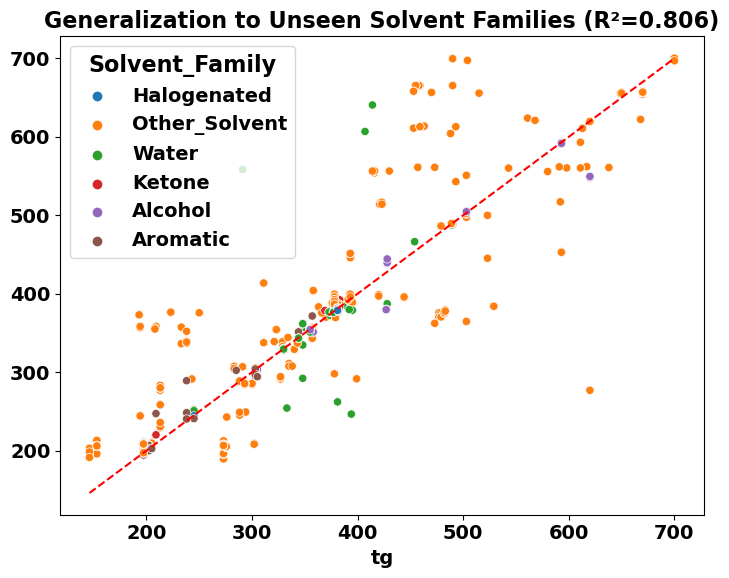

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
try:
    df = pd.read_csv('data_augmented.csv')
except:
    # Dummy data
    data = {
        'polymer_name': ['PMMA', 'PMA', 'PBMA']*20 + ['Polystyrene', 'P-methylstyrene']*20,
        'solvent_name': ['Methanol', 'Ethanol', 'Propanol']*20 + ['Benzene', 'Toluene', 'Xylene']*20,
        'mn': np.random.rand(120)*1000, 'mw': np.random.rand(120)*2000,
        'dens': np.random.rand(120), 'tg': np.random.rand(120)*100
    }
    df = pd.DataFrame(data)

# ==========================================
# 2. CREATE MANUAL CHEMICAL FAMILIES
# ==========================================

def assign_solvent_family(name):
    name = str(name).lower()
    if any(x in name for x in ['benzene', 'toluene', 'xylene', 'phenol', 'styrene']):
        return 'Aromatic'
    elif any(x in name for x in ['ol', 'alcohol', 'methanol', 'ethanol']):
        return 'Alcohol'
    elif any(x in name for x in ['chloro', 'floro', 'bromo']):
        return 'Halogenated'
    elif any(x in name for x in ['one', 'ketone', 'acetone']):
        return 'Ketone'
    elif 'water' in name:
        return 'Water'
    else:
        return 'Other_Solvent'

def assign_polymer_family(name):
    name = str(name).lower()
    if any(x in name for x in ['acrylate', 'pmma', 'pma']):
        return 'Acrylates'
    elif any(x in name for x in ['styrene', 'ps']):
        return 'Styrenics'
    elif any(x in name for x in ['oxide', 'peo', 'peg']):
        return 'Polyoxides'
    elif any(x in name for x in ['chloride', 'pvc']):
        return 'Chlorinated_Polymers'
    else:
        return 'Other_Polymer'

# Apply groupings
df['Solvent_Family'] = df['solvent_name'].apply(assign_solvent_family)
df['Polymer_Family'] = df['polymer_name'].apply(assign_polymer_family)

print("--- 🧪 Chemical Families Created ---")
print("Solvent Families:", df['Solvent_Family'].value_counts().to_dict())
print("Polymer Families:", df['Polymer_Family'].value_counts().to_dict())

# ==========================================
# 3. RUN GROUPED VALIDATION ON FAMILIES
# ==========================================

# Define Features
exclude_cols = ['polymer_name', 'solvent_name', 'polymer_smiles', 'solvent_smiles', 
                'solvent_formula', 'radius_of_gyration', 'Solvent_Category',
                'Solvent_Family', 'Polymer_Family', 'tg']
feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64', 'int64']]

X = df[feature_cols]
y = df['tg']

def test_family_generalization(groups, family_type):
    gkf = GroupKFold(n_splits=5) # 5-Fold split based on FAMILY
    pipeline = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', RobustScaler()),
        ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1))
    ])
    
    try:
        y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, n_jobs=-1)
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        print(f"\n--- Result for Unseen {family_type} Families ---")
        print(f"R²: {r2:.4f} | MAE: {mae:.4f}")
        return y_pred, r2
    except ValueError:
        print(f"\n⚠️ Not enough {family_type} families for 5-fold split. Try fewer splits or more data.")
        return None, 0

# Run Tests
pred_solv_fam, r2_solv_fam = test_family_generalization(df['Solvent_Family'], "Solvent")
pred_poly_fam, r2_poly_fam = test_family_generalization(df['Polymer_Family'], "Polymer")

# Plot Results
plt.figure(figsize=(14, 6))

if pred_solv_fam is not None:
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y, y=pred_solv_fam, hue=df['Solvent_Family'])
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.title(f"Generalization to Unseen Solvent Families (R²={r2_solv_fam:.3f})")

if pred_poly_fam is not None:
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y, y=pred_poly_fam, hue=df['Polymer_Family'])
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.title(f"Generalization to Unseen Polymer Families (R²={r2_poly_fam:.3f})")

plt.tight_layout()
plt.show()

Data loaded.
Features used: ['mn', 'mw', 'dens', 'temperature', 'dielectric_constant', 'molar_refractivity', 'radius_of_gyration_square', 'branching', 'solvent_mol_wt', 'solvent_mol_mr', 'solvent_tpsa', 'solvent_h_donors', 'solvent_h_acceptors']

--- 🧪 Polymer Generalization Test (Unseen Polymers) ---
R² Score: 0.3280
MAE:      84.8005
RMSE:     106.7263

--- 🧪 Solvent Generalization Test (Unseen Solvents) ---
R² Score: 0.9607
MAE:      7.1467
RMSE:     25.8173


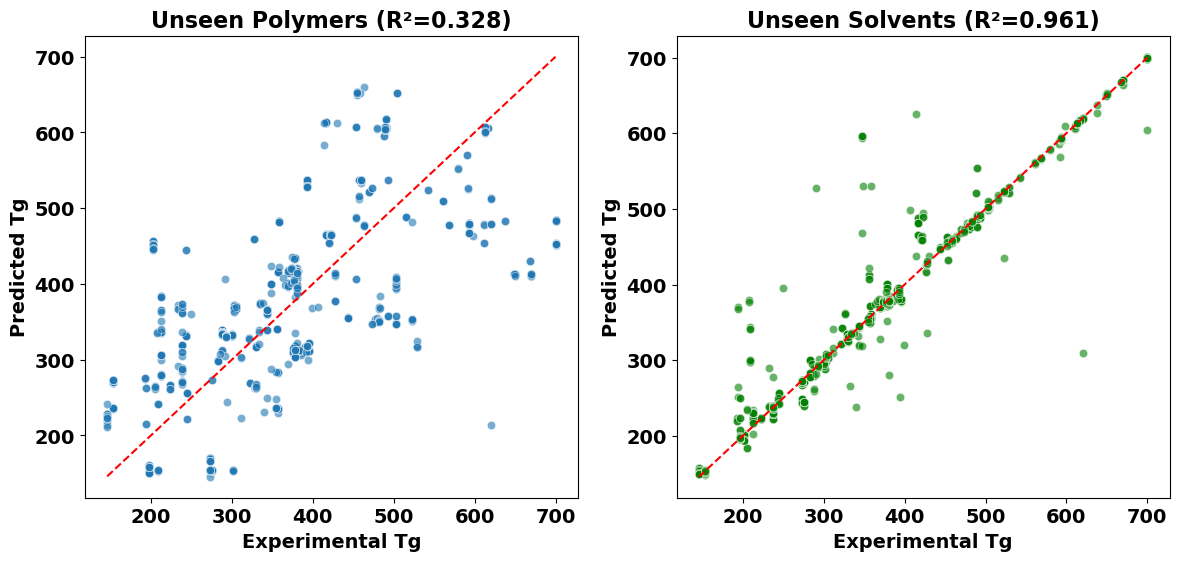

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
try:
    df = pd.read_csv('data_augmented.csv')
    print("Data loaded.")
except:
    # Dummy data creation for testing if file missing
    data = {
        'polymer_name': ['PMMA']*50 + ['PS']*50 + ['PEO']*50,
        'solvent_name': ['Water']*30 + ['Benzene']*40 + ['Toluene']*80,
        'mn': np.random.rand(150)*1000,
        'mw': np.random.rand(150)*2000,
        'dens': np.random.rand(150),
        'tg': np.random.rand(150)*100
    }
    df = pd.DataFrame(data)

# 2. DEFINE FEATURES (Drop Names/SMILES to test Physics only)
exclude_cols = ['polymer_name', 'solvent_name', 'polymer_smiles', 
                'solvent_smiles', 'solvent_formula', 'radius_of_gyration', 'Solvent_Category']
target_col = 'tg'

# Select only numeric physical descriptors
feature_cols = [c for c in df.columns if c not in exclude_cols and c != target_col and df[c].dtype in ['float64', 'int64']]
print(f"Features used: {feature_cols}")

X = df[feature_cols]
y = df[target_col]

# Define Groups
groups_polymer = df['polymer_name']
groups_solvent = df['solvent_name']

# 3. EVALUATION FUNCTION
def evaluate_grouped_split(X, y, groups, group_type="Polymer"):
    gkf = GroupKFold(n_splits=5)
    
    pipeline = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', RobustScaler()),
        ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1))
    ])
    
    y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, n_jobs=-1)
    
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    print(f"\n--- 🧪 {group_type} Generalization Test (Unseen {group_type}s) ---")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    
    return y_pred, r2

# 4. RUN TESTS
pred_poly, r2_poly = evaluate_grouped_split(X, y, groups_polymer, "Polymer")
pred_solv, r2_solv = evaluate_grouped_split(X, y, groups_solvent, "Solvent")

# 5. PLOT
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y, y=pred_poly, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f'Unseen Polymers (R²={r2_poly:.3f})')
plt.xlabel('Experimental Tg')
plt.ylabel('Predicted Tg')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y, y=pred_solv, alpha=0.6, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f'Unseen Solvents (R²={r2_solv:.3f})')
plt.xlabel('Experimental Tg')
plt.ylabel('Predicted Tg')
plt.show()